# Embedding Visualization

This notebook visualizes the image and text embeddings produced by the CLIP-style retrieval system. It uses the saved embedding artifacts created by `scripts/build_index.sh`, so the plots reflect the same trained checkpoint and retrieval split used by the API.

## What This Notebook Covers

- Load project configs and saved retrieval embeddings.
- Inspect embedding shapes, IDs, and metadata.
- Project image/text embeddings into 2D using PCA.
- Compare paired image/text alignment in embedding space.
- Inspect nearest neighbors with cosine similarity.
- Save visualization plots under `artifacts/metadata/plots`.

## Prerequisites

Run these commands from the repository root before using this notebook:

```bash
./scripts/evaluate.sh
./scripts/build_index.sh
```

The notebook expects these files to exist:

```text
artifacts/embeddings/image_corpus.npy
artifacts/embeddings/text_corpus.npy
artifacts/metadata/image_corpus_ids.json
artifacts/metadata/text_corpus_ids.json
```

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "configs").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root containing configs/ and src/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: D:\Projects\CLIP-Style-MultiModal-Retrieval-System


In [3]:
from src.retrieval.storage import load_embedding_artifacts
from src.utils.config import load_retrieval_config, load_retrieval_eval_config

RETRIEVAL_CONFIG = PROJECT_ROOT / "configs" / "retrieval.yaml"
retrieval_cfg = load_retrieval_config(RETRIEVAL_CONFIG)
eval_cfg = load_retrieval_eval_config(RETRIEVAL_CONFIG)

print("Embedding directory:", retrieval_cfg.storage.embeddings_dir)
print("Metadata directory:", retrieval_cfg.storage.metadata_dir)
print("Checkpoint:", eval_cfg.checkpoint.path)
print("Retrieval split:", eval_cfg.runtime.split)

d:\Projects\CLIP-Style-MultiModal-Retrieval-System\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embedding directory: D:\Projects\CLIP-Style-MultiModal-Retrieval-System\artifacts\embeddings
Metadata directory: D:\Projects\CLIP-Style-MultiModal-Retrieval-System\artifacts\metadata
Checkpoint: D:\Projects\CLIP-Style-MultiModal-Retrieval-System\artifacts\checkpoints\clip_best.pt
Retrieval split: test


## Load Saved Embeddings

In [4]:
def assert_embedding_artifacts_exist(name: str) -> None:
    storage = retrieval_cfg.storage
    expected = [
        storage.embeddings_dir / f"{name}.npy",
        storage.metadata_dir / f"{name}_ids.json",
        storage.metadata_dir / f"{name}_meta.json",
    ]
    missing = [path for path in expected if not path.exists()]
    if missing:
        message = "\n".join(str(path) for path in missing)
        raise FileNotFoundError(
            "Missing embedding artifacts. Run './scripts/build_index.sh' first.\n"
            f"Missing files:\n{message}"
        )


assert_embedding_artifacts_exist("image_corpus")
assert_embedding_artifacts_exist("text_corpus")

image_embeddings, image_ids, image_meta = load_embedding_artifacts(
    cfg=retrieval_cfg.storage,
    name="image_corpus",
)
text_embeddings, text_ids, text_meta = load_embedding_artifacts(
    cfg=retrieval_cfg.storage,
    name="text_corpus",
)

image_embeddings = np.asarray(image_embeddings, dtype=np.float32)
text_embeddings = np.asarray(text_embeddings, dtype=np.float32)

print("Image embeddings:", image_embeddings.shape)
print("Text embeddings:", text_embeddings.shape)
print("Image metadata:", image_meta)
print("Text metadata:", text_meta)

Image embeddings: (1272, 256)
Text embeddings: (6360, 256)
Image metadata: {'modality': 'image', 'split': 'test', 'count': 1272, 'dim': 256}
Text metadata: {'modality': 'text', 'split': 'test', 'count': 6360, 'dim': 256}


In [5]:
summary_df = pd.DataFrame(
    [
        {
            "modality": "image",
            "rows": image_embeddings.shape[0],
            "dim": image_embeddings.shape[1],
            "unique_ids": len(set(image_ids)),
        },
        {
            "modality": "text",
            "rows": text_embeddings.shape[0],
            "dim": text_embeddings.shape[1],
            "unique_ids": len(set(text_ids)),
        },
    ]
)
summary_df

,modality,rows,dim,unique_ids
0,image,1272,256,1272
1,text,6360,256,1272


## Sample Embeddings

For visualization, sampling keeps plots readable and PCA fast. The full embeddings remain loaded for nearest-neighbor checks later.

In [6]:
RANDOM_SEED = 42
MAX_PER_MODALITY = 1500

rng = np.random.default_rng(RANDOM_SEED)


def sample_rows(n_rows: int, max_rows: int) -> np.ndarray:
    if n_rows <= max_rows:
        return np.arange(n_rows)
    return np.sort(rng.choice(n_rows, size=max_rows, replace=False))


image_sample_idx = sample_rows(image_embeddings.shape[0], MAX_PER_MODALITY)
text_sample_idx = sample_rows(text_embeddings.shape[0], MAX_PER_MODALITY)

image_sample = image_embeddings[image_sample_idx]
text_sample = text_embeddings[text_sample_idx]

print("Sampled image embeddings:", image_sample.shape)
print("Sampled text embeddings:", text_sample.shape)

Sampled image embeddings: (1272, 256)
Sampled text embeddings: (1500, 256)


## PCA Projection

This uses a NumPy SVD implementation so the notebook does not require an extra `scikit-learn` dependency.

In [7]:
def pca_2d(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centered = matrix - matrix.mean(axis=0, keepdims=True)
    _, singular_values, vh = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ vh[:2].T
    explained = (singular_values[:2] ** 2) / np.sum(singular_values ** 2)
    return coords, explained


combined = np.vstack([image_sample, text_sample])
coords, explained = pca_2d(combined)

plot_df = pd.DataFrame(
    {
        "pc1": coords[:, 0],
        "pc2": coords[:, 1],
        "modality": ["image"] * len(image_sample) + ["text"] * len(text_sample),
    }
)

print(f"Explained variance PC1: {explained[0]:.2%}")
print(f"Explained variance PC2: {explained[1]:.2%}")
plot_df.head()

Explained variance PC1: 9.81%
Explained variance PC2: 8.65%


,pc1,pc2,modality
0,-0.246759,-0.275264,image
1,-0.228262,-0.110287,image
2,0.243056,0.125071,image
3,0.094117,-0.319916,image
4,0.326376,0.198114,image


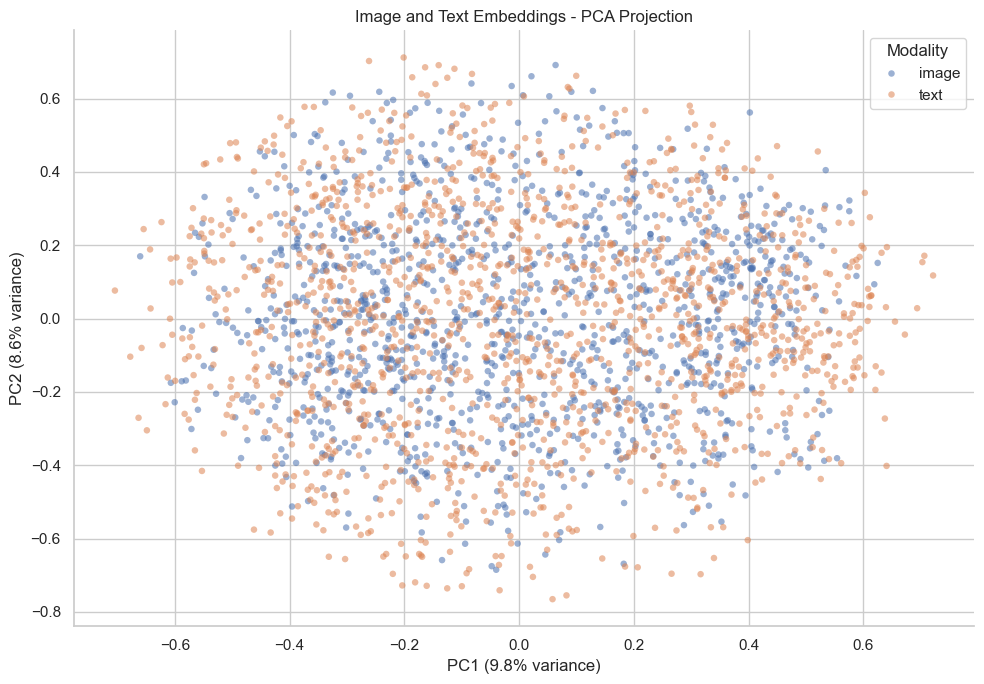

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="modality",
    alpha=0.55,
    s=22,
    linewidth=0,
    ax=ax,
)
ax.set_title("Image and Text Embeddings - PCA Projection")
ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
ax.legend(title="Modality")
plt.tight_layout()

## Paired Alignment View

Image and text embeddings share image IDs. The lines below connect a sampled text embedding to its matching image embedding when both appear in the visualization sample. Shorter lines usually indicate tighter local alignment.

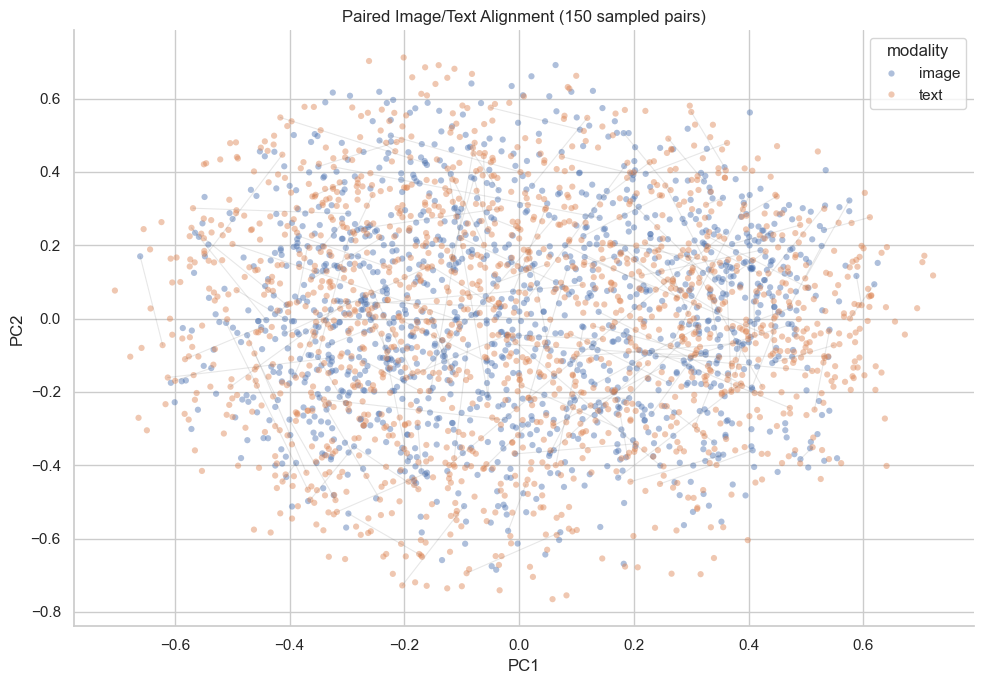

In [9]:
image_id_to_sample_pos = {image_ids[idx]: pos for pos, idx in enumerate(image_sample_idx)}

pairs = []
text_offset = len(image_sample)
for text_pos, text_idx in enumerate(text_sample_idx):
    image_id = text_ids[text_idx]
    image_pos = image_id_to_sample_pos.get(image_id)
    if image_pos is not None:
        pairs.append((image_pos, text_offset + text_pos, image_id))

MAX_LINES = 150
if len(pairs) > MAX_LINES:
    pairs = [pairs[i] for i in rng.choice(len(pairs), size=MAX_LINES, replace=False)]

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="modality",
    alpha=0.45,
    s=20,
    linewidth=0,
    ax=ax,
)
for image_pos, text_pos, _ in pairs:
    ax.plot(
        [coords[image_pos, 0], coords[text_pos, 0]],
        [coords[image_pos, 1], coords[text_pos, 1]],
        color="0.25",
        alpha=0.12,
        linewidth=0.8,
    )
ax.set_title(f"Paired Image/Text Alignment ({len(pairs)} sampled pairs)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()

## Nearest Neighbor Inspection

In [10]:
def l2_normalize(matrix: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.maximum(norms, eps)


image_norm = l2_normalize(image_embeddings)
text_norm = l2_normalize(text_embeddings)


def top_k_matches(query: np.ndarray, gallery: np.ndarray, gallery_ids: list[str], k: int = 5) -> pd.DataFrame:
    scores = gallery @ query
    order = np.argsort(-scores)[:k]
    return pd.DataFrame(
        {
            "rank": np.arange(1, len(order) + 1),
            "item_id": [gallery_ids[i] for i in order],
            "score": [float(scores[i]) for i in order],
        }
    )


example_text_idx = int(text_sample_idx[0])
example_image_id = text_ids[example_text_idx]
print("Example text row:", example_text_idx)
print("Ground-truth image id:", example_image_id)

top_k_matches(text_norm[example_text_idx], image_norm, image_ids, k=10)

Example text row: 7
Ground-truth image id: 101362650.jpg


,rank,item_id,score
0,1,7670346550.jpg,0.725331
1,2,3520617304.jpg,0.632835
2,3,7788997944.jpg,0.625020
3,4,101362650.jpg,0.613307
4,5,6576930023.jpg,0.609662
5,6,6838086484.jpg,0.607132
6,7,7309432042.jpg,0.598178
7,8,8034139464.jpg,0.587877
8,9,8207226893.jpg,0.572243
9,10,6283123175.jpg,0.545804


In [11]:
example_image_idx = int(image_sample_idx[0])
example_image_id = image_ids[example_image_idx]
print("Example image row:", example_image_idx)
print("Ground-truth image id:", example_image_id)

top_k_matches(image_norm[example_image_idx], text_norm, text_ids, k=10)

Example image row: 0
Ground-truth image id: 1007205537.jpg


,rank,item_id,score
0,1,3067467271.jpg,0.545223
1,2,4797050581.jpg,0.539310
2,3,4824522315.jpg,0.536105
3,4,2692396013.jpg,0.535519
4,5,2225231022.jpg,0.530396
5,6,4808039029.jpg,0.526540
6,7,67491882.jpg,0.525054
7,8,4436781562.jpg,0.520981
8,9,434792818.jpg,0.517998
9,10,4808039029.jpg,0.515607


## Similarity Diagnostics

The paired cosine similarity distribution compares each sampled text embedding to the matching image embedding. The random baseline compares each sampled text to a random image.

In [12]:
image_id_to_full_pos = {image_id: idx for idx, image_id in enumerate(image_ids)}

paired_scores = []
for text_idx in text_sample_idx:
    image_pos = image_id_to_full_pos.get(text_ids[text_idx])
    if image_pos is not None:
        paired_scores.append(float(text_norm[text_idx] @ image_norm[image_pos]))

random_image_positions = rng.choice(image_norm.shape[0], size=len(paired_scores), replace=True)
random_scores = [
    float(text_norm[text_sample_idx[i]] @ image_norm[random_image_positions[i]])
    for i in range(len(paired_scores))
]

score_df = pd.DataFrame(
    {
        "cosine_similarity": paired_scores + random_scores,
        "pair_type": ["matched"] * len(paired_scores) + ["random"] * len(random_scores),
    }
)

score_df.groupby("pair_type")["cosine_similarity"].describe()

,count,mean,std,min,25%,50%,75%,max
pair_type,,,,,,,,
matched,1500.0,0.537806,0.137686,-0.075030,0.460918,0.559922,0.644479,0.821594
random,1500.0,0.042810,0.194111,-0.462824,-0.099106,0.020521,0.170807,0.756718


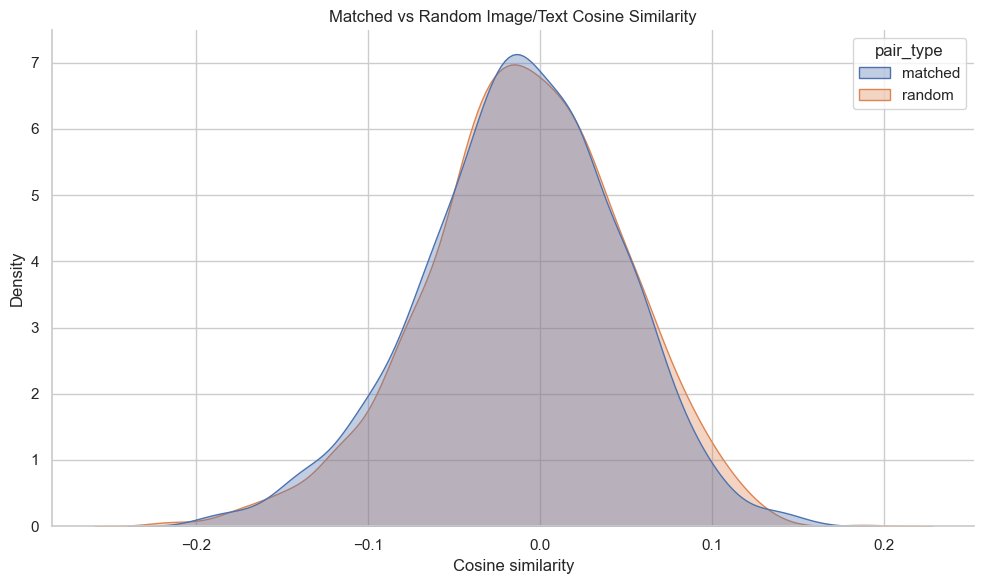

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(
    data=score_df,
    x="cosine_similarity",
    hue="pair_type",
    fill=True,
    common_norm=False,
    alpha=0.35,
    ax=ax,
)
ax.set_title("Matched vs Random Image/Text Cosine Similarity")
ax.set_xlabel("Cosine similarity")
plt.tight_layout()

## Save Plots

In [13]:
PLOTS_DIR = PROJECT_ROOT / "artifacts" / "metadata" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="modality",
    alpha=0.55,
    s=22,
    linewidth=0,
    ax=ax,
)
ax.set_title("Image and Text Embeddings - PCA Projection")
ax.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.tight_layout()
pca_path = PLOTS_DIR / "embedding_pca.png"
fig.savefig(pca_path, dpi=180)
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(
    data=score_df,
    x="cosine_similarity",
    hue="pair_type",
    fill=True,
    common_norm=False,
    alpha=0.35,
    ax=ax,
)
ax.set_title("Matched vs Random Image/Text Cosine Similarity")
ax.set_xlabel("Cosine similarity")
plt.tight_layout()
similarity_path = PLOTS_DIR / "matched_vs_random_similarity.png"
fig.savefig(similarity_path, dpi=180)
plt.close(fig)

print("Saved:", pca_path)
print("Saved:", similarity_path)

Saved: D:\Projects\CLIP-Style-MultiModal-Retrieval-System\artifacts\metadata\plots\embedding_pca.png
Saved: D:\Projects\CLIP-Style-MultiModal-Retrieval-System\artifacts\metadata\plots\matched_vs_random_similarity.png


## Reading The Plots

- Stronger alignment usually shows image/text points mixed together rather than separated by modality.
- Matched-pair cosine similarities should be shifted to the right of random-pair similarities.
- PCA is only a compressed diagnostic view. Use `scripts/evaluate.sh` and Recall@K for final retrieval quality.